In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving amazon_sales_dataset.csv to amazon_sales_dataset (1).csv
User uploaded file "amazon_sales_dataset (1).csv" with length 1877207 bytes


In [31]:
uploaded = pd.read_csv(fn)
uploaded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  object 
 1   order_date      10000 non-null  object 
 2   ship_date       10000 non-null  object 
 3   delivery_date   10000 non-null  object 
 4   order_status    10000 non-null  object 
 5   customer_id     10000 non-null  object 
 6   customer_name   10000 non-null  object 
 7   country         10000 non-null  object 
 8   state           10000 non-null  object 
 9   city            10000 non-null  object 
 10  product_id      10000 non-null  object 
 11  product_name    10000 non-null  object 
 12  category        10000 non-null  object 
 13  sub_category    10000 non-null  object 
 14  brand           10000 non-null  object 
 15  quantity        10000 non-null  int64  
 16  unit_price      10000 non-null  float64
 17  discount        10000 non-null  

In [32]:
# remove missing values
uploaded = uploaded.dropna()

# convert data types
uploaded['order_date'] = pd.to_datetime(uploaded['order_date'])
uploaded['quantity'] = pd.to_numeric(uploaded['quantity'])
uploaded['unit_price'] = pd.to_numeric(uploaded['unit_price'])

In [33]:
uploaded['Sales'] = uploaded['quantity'] * uploaded['unit_price']

uploaded.head()

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method,Sales
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card,127403.37
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,Home,Furniture,Davis LLC,2,36138.76,0.24,112.96,55043.8752,COD,72277.52
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI,188595.72
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,Electronics,Laptop,"Sandoval, Buckley and Solis",1,18487.99,0.06,114.15,17492.8606,Card,18487.99
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,Home,Kitchen,"Key, Bautista and Bowen",1,1742.25,0.10,40.47,1608.4950,UPI,1742.25


In [34]:
uploaded['Month'] = uploaded['order_date'].dt.month

monthly_sales = uploaded.groupby('Month')['Sales'].sum()

monthly_sales

,Sales
Month,
1,5.754059e+08
2,1.788087e+08


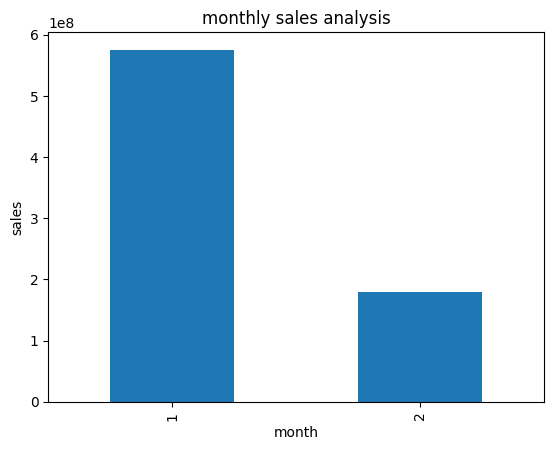

In [35]:
import os

plt.figure()

monthly_sales.plot(kind='bar')

plt.title("monthly sales analysis")
plt.xlabel("month")
plt.ylabel("sales")

# Create the 'images' directory if it doesn't exist
output_dir = 'images'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "charts.png"))

plt.show()

In [36]:
product_sales = uploaded.groupby('product_name')['quantity'].sum().sort_values(ascending=False)

product_sales.head(10)

,quantity
product_name,
maintain,78
level,68
include,68
alone,67
hear,65
trouble,65
letter,63
dinner,63
radio,63


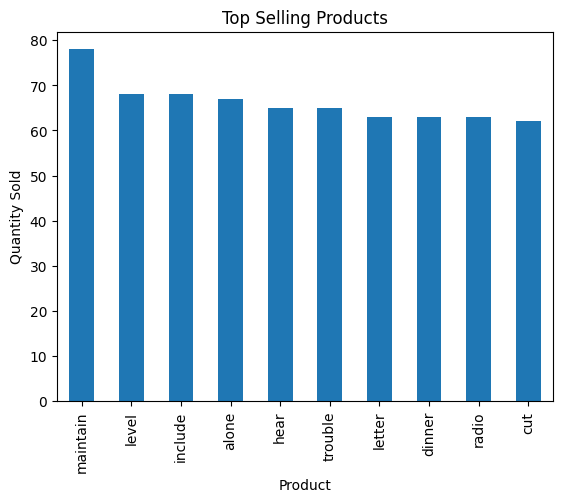

In [37]:
plt.figure()

product_sales.head(10).plot(kind='bar')

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

In [38]:
city_sales = uploaded.groupby('city')['Sales'].sum()

city_sales

,Sales
city,
Aaronchester,28789.05
Aaronfurt,224989.50
Aaronland,92692.89
Aaronstad,40182.86
Aarontown,17206.08
...,...
Zacharyville,148497.68
Zamoramouth,71454.80
Zimmermanberg,27932.44


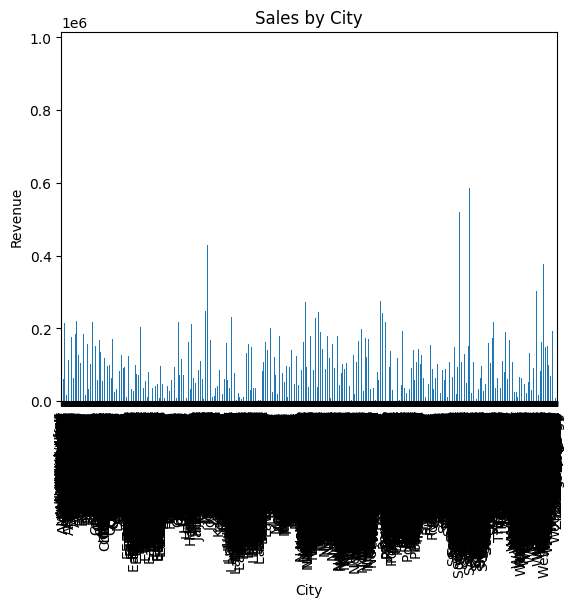

In [39]:
plt.figure()

city_sales.plot(kind='bar')

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.show()

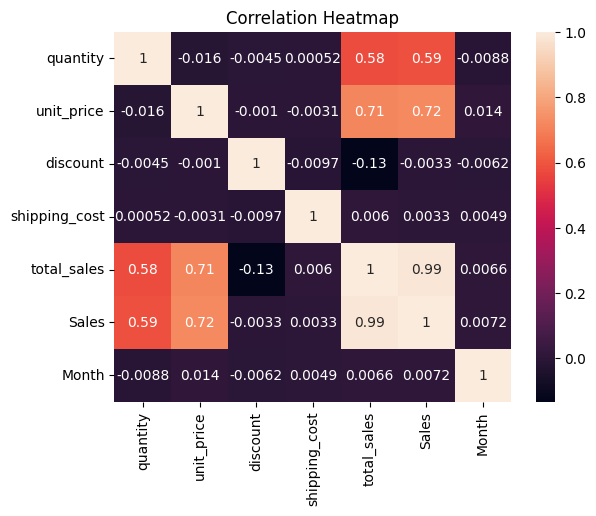

In [40]:
plt.figure()

sns.heatmap(uploaded.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()